In [1]:
import numpy
import pandas
import os
import numpy
import scipy
import csv
import mod_utils as utils
import matplotlib.pyplot as plt


def attempt_to_print_halfwidth(list1):
    y_min = []
    y_max = []
    val = []
    time = []
    for idx, list_item in enumerate(list1.df_list):
        # Assuming there's a column named 'time' that defines the time axis
        # If not present, replace it with appropriate logic to define time.

        try:
            #print('reading frame: ', list1.timesteps[idx])
            for i in range(1, len(list_item["min_mixWidth"])):
                check_val = list_item["min_mixWidth"][i-1]*list_item["min_mixWidth"][i]
                if check_val < 0:
                    min_idx = i
            for i in range(1, len(list_item["max_mixWidth"])):
                check_val = list_item["max_mixWidth"][i-1]*list_item["max_mixWidth"][i]
                if check_val < 0:
                    max_idx = i   
            min_idx2 = numpy.where(list_item["min_mixWidth"][:-1] * list_item["min_mixWidth"][1:] < 0)[0][0] + 1
            max_idx2 = numpy.where(list_item["max_mixWidth"][:-1] * list_item["max_mixWidth"][1:] < 0)[0][0] + 1
            #print(min_idx, min_idx2)
            #print(max_idx, max_idx2)
            y_min.append(list_item["y_dat"][min_idx])
            y_max.append(list_item["y_dat"][max_idx])
            diff = float((y_max[-1]-y_min[-1]))/(2*list1.wavelength)
            val.append(diff)
            time.append(list1.timesteps[idx])#*nonDim_T)
        except IndexError:
            print(f"Sign change not found in DataFrame {idx}. Skipping.")
            continue

    plt.figure(figsize=(10, 6))
    plt.scatter(time, val, label='', marker='o')
    #plt.scatter(list1.timesteps, y_max, label='Max Position', marker='x')

    plt.xlabel('Time')
    plt.ylabel('y_dat Value')
    plt.title('Plot of y_dat at Min and Max Positions Over Time')
    plt.legend()
    plt.grid(True)

    plt.show()

In [11]:
math_vars = {
    'high_rho': 3,
    'low_rho' : 1.0,
    'high_visc' : 0.01, #dynamic
    'low_visc' : 0.01,
    'wavelength' : 1,
    'grev': 1,
    'x_L' : 1,
    'y_L' : 4,
    'delta_h': 0.005,
    'timestep': 0.0035,
    'time_end': 5,
    'maxWidthCutOff': 0.01
}

model = utils.dynamic_model(math_vars)
model.set_nondim_consts(ref_l = 'x_L',
                        ref_rho = 'high_rho',
                        ref_grev = 'grev',
                        ref_visc = 'low_visc',
                        ref_visc_kin = lambda ref_visc, ref_rho: ref_visc/ref_rho,
                        ref_u = lambda ref_grev, ref_l: numpy.sqrt(ref_grev*ref_l)
                        )

model.calculate_nondim_nums(atwood = {},
                            reynolds = {},
                            froude = {},
                            grashof = {},
                            #ren2 = lambda ref_grev, ref_l, ref_rho, ref_visc: (numpy.sqrt(numpy.pow(ref_l,3)*ref_grev)*ref_rho)/ref_visc
                            )

{'atwood_num': 0.5, 'reynolds_num': np.float64(300.0), 'froude_num': np.float64(1.0), 'grashof_num': np.float64(0.01125)}


In [12]:
name_vars = {
    'x_dat': "X (m)",
    'y_dat': "Y (m)",
    'v_x': "Velocity[i] (m/s)",
    'v_y': "Velocity[j] (m/s)",
    'rel_v_x': "Relative Velocity[i] (m/s)",
    "rel_v_y": "Relative Velocity[j] (m/s)",
    'volFrac_high': "Volume Fraction of high_rho",
    'volFrac_low': "Volume Fraction of low_rho",
    'min_mixWidth': "minMixWidthEval",
    'max_mixWidth': "maxMixWidthEval",
    'massFlux': "Report: massImbalance_highRho (kg)",
    'mean_rho': "Density (kg/m^3)"
}

freq = 2
range_var = list(range(int(1/(freq*model.params["timestep"]) + 1), int(model.params["time_end"]/model.params["timestep"]) + 1, int(1/(freq*model.params["timestep"]))+ 1))
model.params['timesteps'] = []
[model.params['timesteps'].append(i*model.params["timestep"]) for i in range_var]
model.params["nondim_time_time"] = []
model.set_nondim_consts(overwrite= True, ref_t = lambda atwood_num: numpy.sqrt(atwood_num))

print(model.params['ref_t'])
for i in model.params['timesteps']:
    model.params["nondim_time_time"].append(i*model.params["ref_t"])
print("timesteps of observation:", model.params["nondim_time_time"])
dir = r'D:\thesis\rayleigh_taylor\test01'
name = 'isosurface_table_'
name_append = '.csv'

model.set_solution_data(dir, name_append, range_var, name, name_vars)


0.7071067811865476
timesteps of observation: [np.float64(0.3539069439838671), np.float64(0.7078138879677341), np.float64(1.0617208319516012), np.float64(1.4156277759354683), np.float64(1.7695347199193352), np.float64(2.1234416639032023), np.float64(2.4773486078870697), np.float64(2.8312555518709366), np.float64(3.1851624958548035)]


In [13]:
range_var

[143, 286, 429, 572, 715, 858, 1001, 1144, 1287]

In [14]:
y_s = []
y_b = []
v_y_s = []
v_y_b = []
val = []
alpha = []
time = []
nondimtime = []
h_0 = 0
for idx, working_df in enumerate(model.solution_data):
    min_val = working_df["y_dat"].min()
    max_val = working_df["y_dat"].max()
    y_s.append(min_val)
    y_b.append(max_val)
    h_t = (max_val - min_val)/2
    if idx == 0:
        h_0 = h_t
    #print(h_t, h_0)
    val.append(h_t)
    time.append(model.params['timesteps'][idx])
    nondimtime.append(model.params['nondim_time_time'][idx])
    #sqrt(ht^0.5 - h_(0)^(0.5)/((Ag)^(0.5)*(t-t0))
    if idx > 0:
        val2 = numpy.sqrt((numpy.sqrt(h_t) - numpy.sqrt(h_0)/(numpy.sqrt(model.params['atwood_num'] * numpy.abs(model.params['grev']))*(model.params['timesteps'][idx] - model.params['timesteps'][0]))))
    else:
        val2 = 0
    alpha.append(val2)
    min_idx = numpy.argmin(working_df["y_dat"])
    max_idx = numpy.argmax(working_df["y_dat"])
    #v_y_b.append((working_df["v_y"][max_idx]/outlist.FroudeConst))
    v_y_s.append(working_df["v_y"][min_idx])

C:\Users\harsh\AppData\Local\Temp\ipykernel_8580\1464022966.py:24: RuntimeWarning: invalid value encountered in sqrt
  val2 = numpy.sqrt((numpy.sqrt(h_t) - numpy.sqrt(h_0)/(numpy.sqrt(model.params['atwood_num'] * numpy.abs(model.params['grev']))*(model.params['timesteps'][idx] - model.params['timesteps'][0]))))


In [8]:
plt.figure(figsize=(8, 5))
plt.plot(nondimtime, v_y_b, label='val', color='green')
plt.xlabel("Non-dimensional Time")
plt.ylabel("Value (val)")
plt.title("val vs Non-dimensional Time")
plt.legend()
plt.grid(True)
plt.show()

ValueError: x and y must have same first dimension, but have shapes (6,) and (0,)

Error in callback <function flush_figures at 0x0000021F6EBABC10> (for post_execute), with arguments args (),kwargs {}:


KeyboardInterrupt: 

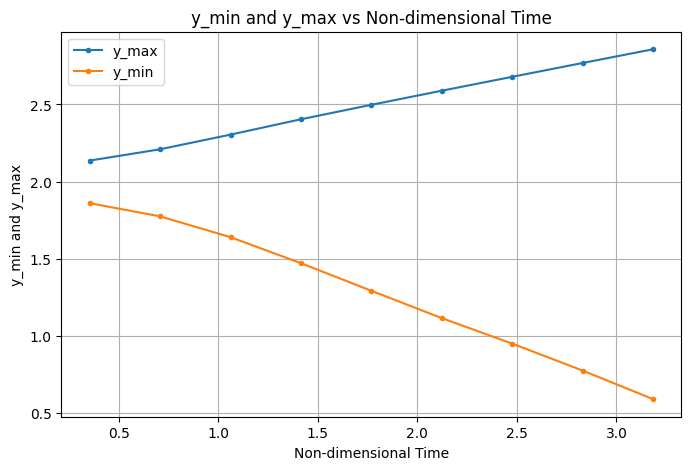

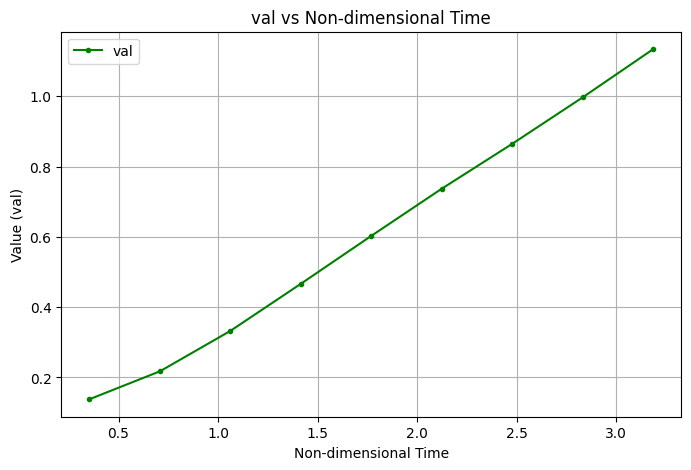

In [15]:
# Plot y_max and y_min on the same graph
plt.figure(figsize=(8, 5))
plt.plot(nondimtime, y_b, label='y_max', marker = ".")
plt.plot(nondimtime, y_s, label='y_min', marker = '.')
plt.xlabel("Non-dimensional Time")
plt.ylabel("y_min and y_max")
plt.title("y_min and y_max vs Non-dimensional Time")
plt.legend()
plt.grid(True)
plt.show()

# Plot val against nondimtime
plt.figure(figsize=(8, 5))
plt.plot(nondimtime, val, label='val', color='green', marker = '.')
plt.xlabel("Non-dimensional Time")
plt.ylabel("Value (val)")
plt.title("val vs Non-dimensional Time")
plt.legend()
plt.grid(True)
plt.show()